In [5]:
import numpy as np
import pandas as pd

from utils import PendulumsData, ResonanceFitData, bar_chart

In [6]:
cols = ["mass A", "mass B", "mass C", "mass D"]
labels = ["97cm", "99cm", "99.5cm", "100cm"]
lengths = np.array([0.97, 0.99, 0.995, 1.0])
L_d = 1.0

In [7]:
data = pd.read_csv("../data/session-4/from5toEnd.csv")
# data['t'] += 300
data = data.dropna()

pendulum_data = PendulumsData(cols=cols, labels=labels, lengths=lengths, data=data)
pendulum_data.preprocess_offsets()

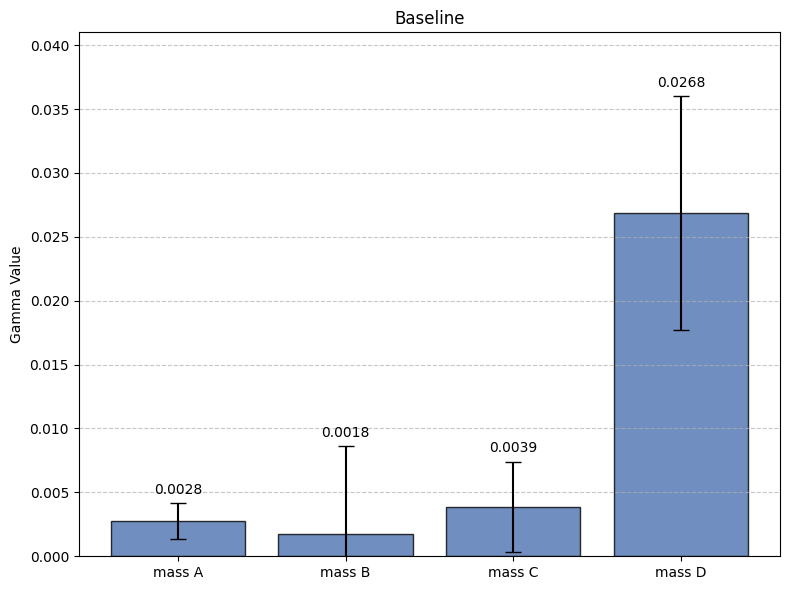

In [8]:
res_fit = ResonanceFitData(L_d, pendulum_data)
res_fit.fit_single_pendulums()

data_to_plot: tuple[list[str], list[float], list[float]] = ([], [], [])

for col in res_fit.envelope_data.cols:
    gamma, gamma_err = res_fit.single_pendulum_gamma[col]
    data_to_plot[0].append(col)
    data_to_plot[1].append(gamma)
    data_to_plot[2].append(gamma_err)

bar_chart(data_to_plot, title="Baseline")